In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from scipy.stats import linregress

from scipy.stats import pearsonr, spearmanr

from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    mean_squared_error,
    r2_score
)

## Load Dataset

In [89]:

df = pd.read_csv("../data/processed/merged_dataset.csv")

print(df.shape)
df.head()

(100, 1096)


,file_id,filepath,age,sex_x,brain_health_score,total_cognition_score,fluid_cognition_score,crystallized_cognition_score,lhl_1,lhl_2,...,BT2.h.7,SGOT2.h.8,SGPT,Family _History,Medical_History,Barthel_scale,MRS_scale,NIHSS_scale,AHI_1_B,subject_id
0,SN1,sleep_data/SN1.edf,65.0,1,-0.27464,-0.01407,-0.10628,0.08692,0.022346,-0.994057,...,1.14,29.8,25.7,NaN,NaN,100.0,0.0,0.0,50.8,SN1
1,SN2,sleep_data/SN2.edf,60.0,1,-0.36531,0.06125,-0.09295,0.30379,0.152037,-0.997863,...,NaN,30.1,26.8,NaN,NaN,100.0,0.0,0.0,6.5,SN2
2,SN3,sleep_data/SN3.edf,49.0,1,0.24275,0.49118,0.45108,0.23969,0.210161,-0.920484,...,NaN,NaN,NaN,NaN,NaN,100.0,0.0,0.0,41.1,SN3
3,SN4,sleep_data/SN4.edf,47.0,1,0.16931,0.49646,0.48187,0.24427,0.123935,-0.969290,...,0.78,23,25.0,1,NaN,100.0,0.0,0.0,39.1,SN4
4,SN5,sleep_data/SN5.edf,39.0,1,0.00631,0.31138,0.31247,-0.02889,0.179273,-0.829033,...,0.70,30,40.0,NaN,NaN,100.0,0.0,0.0,1.9,SN5


In [90]:
print(df.columns)

Index(['file_id', 'filepath', 'age', 'sex_x', 'brain_health_score',
       'total_cognition_score', 'fluid_cognition_score',
       'crystallized_cognition_score', 'lhl_1', 'lhl_2',
       ...
       'BT2.h.7', 'SGOT2.h.8', 'SGPT', 'Family _History', 'Medical_History',
       'Barthel_scale ', 'MRS_scale', 'NIHSS_scale', 'AHI_1_B', 'subject_id'],
      dtype='str', length=1096)


In [91]:
df.columns.tolist()

['file_id',
 'filepath',
 'age',
 'sex_x',
 'brain_health_score',
 'total_cognition_score',
 'fluid_cognition_score',
 'crystallized_cognition_score',
 'lhl_1',
 'lhl_2',
 'lhl_3',
 'lhl_4',
 'lhl_5',
 'lhl_6',
 'lhl_7',
 'lhl_8',
 'lhl_9',
 'lhl_10',
 'lhl_11',
 'lhl_12',
 'lhl_13',
 'lhl_14',
 'lhl_15',
 'lhl_16',
 'lhl_17',
 'lhl_18',
 'lhl_19',
 'lhl_20',
 'lhl_21',
 'lhl_22',
 'lhl_23',
 'lhl_24',
 'lhl_25',
 'lhl_26',
 'lhl_27',
 'lhl_28',
 'lhl_29',
 'lhl_30',
 'lhl_31',
 'lhl_32',
 'lhl_33',
 'lhl_34',
 'lhl_35',
 'lhl_36',
 'lhl_37',
 'lhl_38',
 'lhl_39',
 'lhl_40',
 'lhl_41',
 'lhl_42',
 'lhl_43',
 'lhl_44',
 'lhl_45',
 'lhl_46',
 'lhl_47',
 'lhl_48',
 'lhl_49',
 'lhl_50',
 'lhl_51',
 'lhl_52',
 'lhl_53',
 'lhl_54',
 'lhl_55',
 'lhl_56',
 'lhl_57',
 'lhl_58',
 'lhl_59',
 'lhl_60',
 'lhl_61',
 'lhl_62',
 'lhl_63',
 'lhl_64',
 'lhl_65',
 'lhl_66',
 'lhl_67',
 'lhl_68',
 'lhl_69',
 'lhl_70',
 'lhl_71',
 'lhl_72',
 'lhl_73',
 'lhl_74',
 'lhl_75',
 'lhl_76',
 'lhl_77',
 'lhl_78',


In [92]:
print(df.shape)

(100, 1096)


## EEG Features

In [93]:
feature_cols = [
    col for col in df.columns
    if col.startswith("lhl_")
]

print(len(feature_cols))

1024


## Target

In [94]:
[col for col in df.columns if "AHI" in col.upper()]

['AHI_1_B']

In [95]:
X = df[feature_cols]

y = df["AHI_1_B"]

print(X.shape)
print(y.shape)

(100, 1024)
(100,)


## Check Missing Values

In [96]:
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

Missing values in X: 0
Missing values in y: 0


## LOSO + Linear Regression

In [97]:
loo = LeaveOneOut()

actual_values = []
predicted_values = []

model = LinearRegression()

for train_idx, test_idx in loo.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    # Train model
    model.fit(X_train, y_train)

    # Predict
    prediction = model.predict(X_test)

    # Clip negative predictions to 0
    prediction = np.clip(prediction, 0, None)

    actual_values.append(y_test.values[0])
    predicted_values.append(prediction[0])


print("LOSO completed!")

LOSO completed!


## Evaluation Metrics

In [98]:
mae = mean_absolute_error(
    actual_values,
    predicted_values
)

medae = median_absolute_error(
    actual_values,
    predicted_values
)

rmse = np.sqrt(
    mean_squared_error(
        actual_values,
        predicted_values
    )
)

r2 = r2_score(
    actual_values,
    predicted_values
)

pearson_r, pearson_p = pearsonr(
    actual_values,
    predicted_values
)

spearman_rho, spearman_p = spearmanr(
    actual_values,
    predicted_values
)

print("LOSO Linear Regression Results")
print("-" * 60)

print(f"MAE            = {mae:.4f}")
print(f"Median AE      = {medae:.4f}")
print(f"RMSE           = {rmse:.4f}")
print(f"R² Score       = {r2:.4f}")

print(f"Pearson r      = {pearson_r:.4f}")
print(f"Pearson p      = {pearson_p:.6f}")

print(f"Spearman rho   = {spearman_rho:.4f}")
print(f"Spearman p     = {spearman_p:.6f}")

LOSO Linear Regression Results
------------------------------------------------------------
MAE            = 15.1164
Median AE      = 12.1178
RMSE           = 19.9616
R² Score       = -0.0300
Pearson r      = 0.5120
Pearson p      = 0.000000
Spearman rho   = 0.4997
Spearman p     = 0.000000


In [99]:
linear_mae = mae
linear_medae = medae
linear_rmse = rmse
linear_r2 = r2
linear_pearson = pearson_r
linear_spearman = spearman_rho

## Actual vs Predicted Scatter Plot

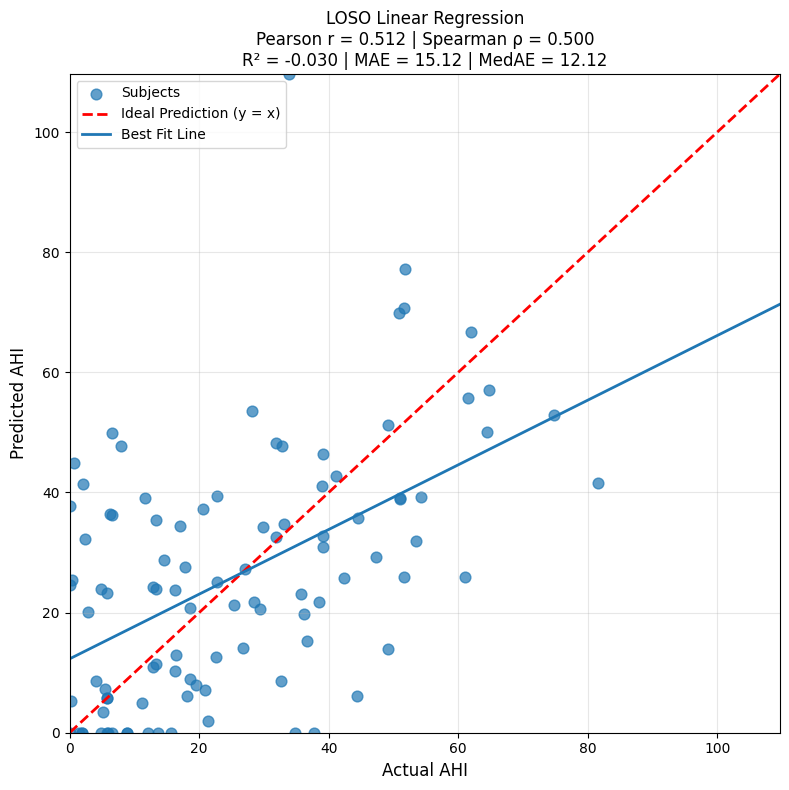

In [100]:
# Fit regression line
fit = linregress(
    actual_values,
    predicted_values
)

slope = fit.slope
intercept = fit.intercept

# Maximum value for axes
max_val = max(
    max(actual_values),
    max(predicted_values)
)

# Create smooth x values
x_line = np.linspace(
    0,
    max_val,
    500
)

# Best-fit line
y_fit = slope * x_line + intercept

# Create figure
plt.figure(figsize=(8, 8))

# Scatter points
plt.scatter(
    actual_values,
    predicted_values,
    s=60,
    alpha=0.7,
    label="Subjects"
)

# Ideal prediction line (y = x)
plt.plot(
    [0, max_val],
    [0, max_val],
    "r--",
    linewidth=2,
    label="Ideal Prediction (y = x)"
)

# Regression fit line
plt.plot(
    x_line,
    y_fit,
    linewidth=2,
    label="Best Fit Line"
)

# Axis labels
plt.xlabel(
    "Actual AHI",
    fontsize=12
)

plt.ylabel(
    "Predicted AHI",
    fontsize=12
)

# Title
plt.title(
    f"LOSO Linear Regression\n"
    f"Pearson r = {pearson_r:.3f} | "
    f"Spearman ρ = {spearman_rho:.3f}\n"
    f"R² = {r2:.3f} | "
    f"MAE = {mae:.2f} | "
    f"MedAE = {medae:.2f}"
)

# Force axes to start from zero
plt.xlim(0, max_val)
plt.ylim(0, max_val)

# Style
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

# Save figure
plt.savefig(
    "../outputs/plots/actual_vs_predicted_ahi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [101]:
print(f"Best Fit Line: y = {slope:.4f}x + {intercept:.4f}")

Best Fit Line: y = 0.5383x + 12.3022


## Ridge LOSO Training

In [102]:
loo = LeaveOneOut()

ridge_actual = []
ridge_predicted = []

model = Ridge(alpha=1.0)

for train_idx, test_idx in loo.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    # Clip negative AHI values
    prediction = np.clip(prediction, 0, None)

    ridge_actual.append(y_test.values[0])
    ridge_predicted.append(prediction[0])

print("Ridge LOSO completed!")

Ridge LOSO completed!


### Ridge Predictions

In [103]:
ridge_results = pd.DataFrame({
    "Actual_AHI": ridge_actual,
    "Predicted_AHI": ridge_predicted
})


ridge_results.head()

,Actual_AHI,Predicted_AHI
0,50.8,56.041660
1,6.5,11.747969
2,41.1,39.868532
3,39.1,47.595867
4,1.9,0.000000


## Compute Metrics

In [104]:
ridge_actual = np.array(ridge_actual)
ridge_predicted = np.array(ridge_predicted)

mae = mean_absolute_error(
    ridge_actual,
    ridge_predicted
)

medae = median_absolute_error(
    ridge_actual,
    ridge_predicted
)

rmse = np.sqrt(
    mean_squared_error(
        ridge_actual,
        ridge_predicted
    )
)

r2 = r2_score(
    ridge_actual,
    ridge_predicted
)

pearson_corr, _ = pearsonr(
    ridge_actual,
    ridge_predicted
)

spearman_corr, _ = spearmanr(
    ridge_actual,
    ridge_predicted
)

print(f"MAE      : {mae:.4f}")
print(f"MedAE    : {medae:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"R²       : {r2:.4f}")
print(f"Pearson  : {pearson_corr:.4f}")
print(f"Spearman : {spearman_corr:.4f}")

MAE      : 13.4394
MedAE    : 10.4042
RMSE     : 17.3797
R²       : 0.2192
Pearson  : 0.5533
Spearman : 0.5252


In [105]:
ridge_mae = mae
ridge_medae = medae
ridge_rmse = rmse
ridge_r2 = r2
ridge_pearson = pearson_corr
ridge_spearman = spearman_corr

## Plot

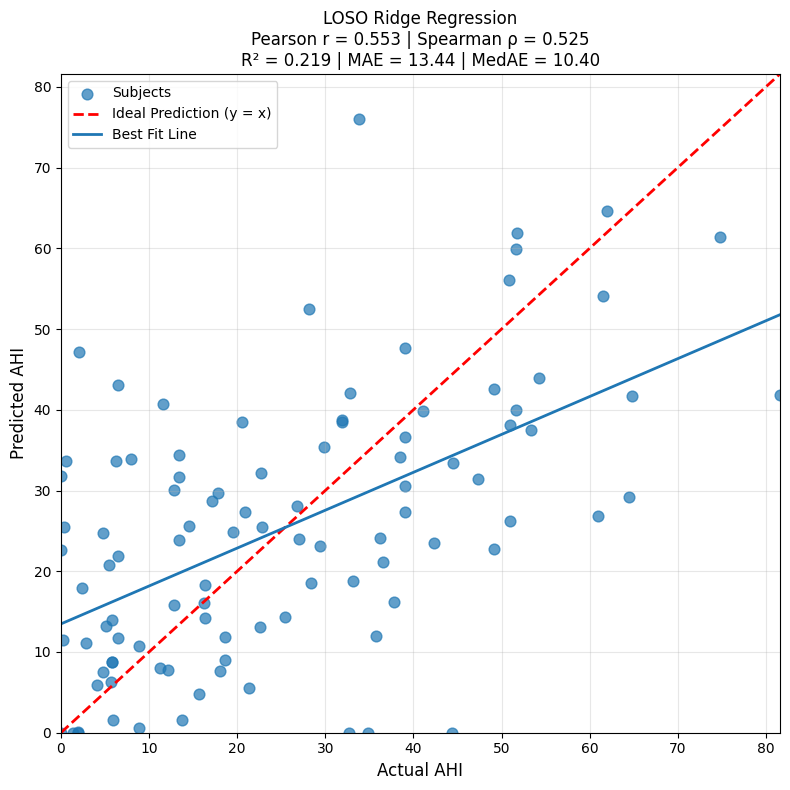

Ridge plot saved successfully!


In [106]:
# Metrics
medae = median_absolute_error(
    ridge_actual,
    ridge_predicted
)

# Fit regression line
fit = linregress(
    ridge_actual,
    ridge_predicted
)

slope = fit.slope
intercept = fit.intercept

# Maximum value for axes
max_val = max(
    max(ridge_actual),
    max(ridge_predicted)
)

# Create smooth x values
x_line = np.linspace(
    0,
    max_val,
    500
)

# Best-fit line
y_fit = slope * x_line + intercept

# Create figure
plt.figure(figsize=(8, 8))

# Scatter points
plt.scatter(
    ridge_actual,
    ridge_predicted,
    s=60,
    alpha=0.7,
    label="Subjects"
)

# Ideal prediction line (y = x)
plt.plot(
    [0, max_val],
    [0, max_val],
    "r--",
    linewidth=2,
    label="Ideal Prediction (y = x)"
)

# Regression fit line
plt.plot(
    x_line,
    y_fit,
    linewidth=2,
    label="Best Fit Line"
)

# Axis labels
plt.xlabel(
    "Actual AHI",
    fontsize=12
)

plt.ylabel(
    "Predicted AHI",
    fontsize=12
)

# Title
plt.title(
    f"LOSO Ridge Regression\n"
    f"Pearson r = {pearson_corr:.3f} | "
    f"Spearman ρ = {spearman_corr:.3f}\n"
    f"R² = {r2:.3f} | "
    f"MAE = {mae:.2f} | "
    f"MedAE = {medae:.2f}"
)

# Force axes to start from zero
plt.xlim(0, max_val)
plt.ylim(0, max_val)

# Style
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

# Save figure
plt.savefig(
    "../outputs/plots/ridge_actual_vs_predicted_ahi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Ridge plot saved successfully!")

## Lasso LOSO

In [107]:
loo = LeaveOneOut()

lasso_actual = []
lasso_predicted = []

model = Lasso(
    alpha=1.0,
    max_iter=10000
)

for train_idx, test_idx in loo.split(X):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    # Clip negative AHI values
    prediction = np.clip(
        prediction,
        0,
        None
    )

    lasso_actual.append(
        y_test.values[0]
    )

    lasso_predicted.append(
        prediction[0]
    )

print("Lasso LOSO completed!")

Lasso LOSO completed!


## Metrics

In [108]:
lasso_actual = np.array(lasso_actual)
lasso_predicted = np.array(lasso_predicted)

mae = mean_absolute_error(
    lasso_actual,
    lasso_predicted
)

medae = median_absolute_error(
    lasso_actual,
    lasso_predicted
)

rmse = np.sqrt(
    mean_squared_error(
        lasso_actual,
        lasso_predicted
    )
)

r2 = r2_score(
    lasso_actual,
    lasso_predicted
)

pearson_r, _ = pearsonr(
    lasso_actual,
    lasso_predicted
)

spearman_rho, _ = spearmanr(
    lasso_actual,
    lasso_predicted
)

print(f"MAE      : {mae:.4f}")
print(f"MedAE    : {medae:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"R²       : {r2:.4f}")
print(f"Pearson  : {pearson_r:.4f}")
print(f"Spearman : {spearman_rho:.4f}")

MAE      : 16.1128
MedAE    : 15.2891
RMSE     : 19.0262
R²       : 0.0642
Pearson  : 0.2554
Spearman : 0.2569


In [109]:
lasso_mae = mae
lasso_medae = medae
lasso_rmse = rmse
lasso_r2 = r2
lasso_pearson = pearson_r
lasso_spearman = spearman_rho

### Plot

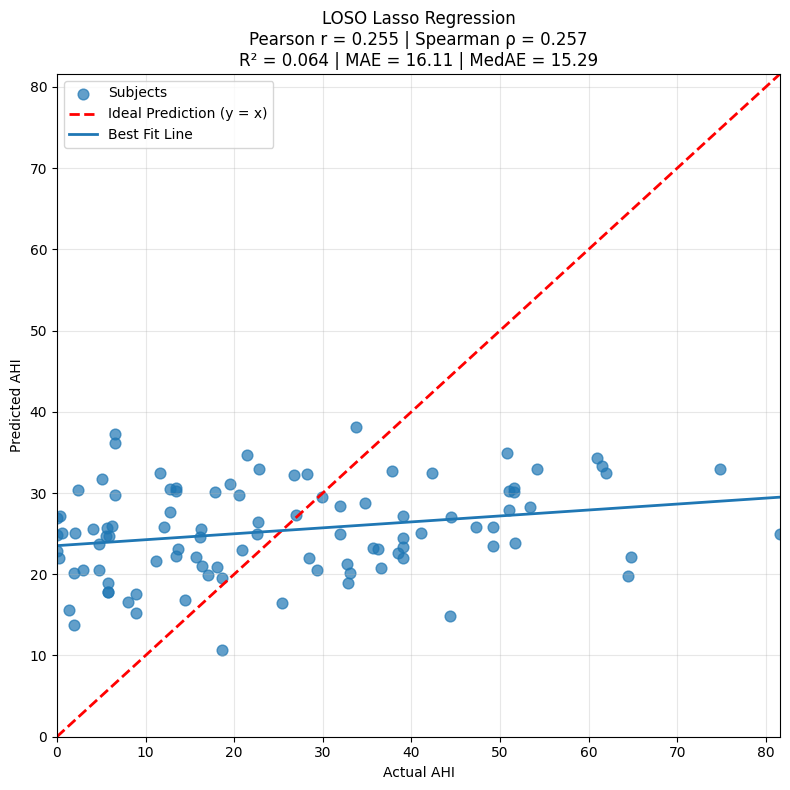

In [110]:
from scipy.stats import linregress

fit = linregress(
    lasso_actual,
    lasso_predicted
)

slope = fit.slope
intercept = fit.intercept

max_val = max(
    max(lasso_actual),
    max(lasso_predicted)
)

x_line = np.linspace(
    0,
    max_val,
    500
)

y_fit = slope * x_line + intercept

plt.figure(figsize=(8,8))

plt.scatter(
    lasso_actual,
    lasso_predicted,
    s=60,
    alpha=0.7,
    label="Subjects"
)

plt.plot(
    [0, max_val],
    [0, max_val],
    "r--",
    linewidth=2,
    label="Ideal Prediction (y = x)"
)

plt.plot(
    x_line,
    y_fit,
    linewidth=2,
    label="Best Fit Line"
)

plt.xlabel("Actual AHI")
plt.ylabel("Predicted AHI")

plt.title(
    f"LOSO Lasso Regression\n"
    f"Pearson r = {pearson_r:.3f} | "
    f"Spearman ρ = {spearman_rho:.3f}\n"
    f"R² = {r2:.3f} | "
    f"MAE = {mae:.2f} | "
    f"MedAE = {medae:.2f}"
)

plt.xlim(0, max_val)
plt.ylim(0, max_val)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/plots/lasso_actual_vs_predicted_ahi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [111]:
comparison_df = pd.DataFrame({
    "Actual_AHI": actual_values,          # Linear actual
    "Linear_Predicted": predicted_values,
    "Ridge_Predicted": ridge_predicted,
    "Lasso_Predicted": lasso_predicted
})

comparison_df.to_csv(
    "../outputs/linear_ridge_lasso_predictions.csv",
    index=False
)

print("CSV saved successfully!")

comparison_df.head()

CSV saved successfully!


,Actual_AHI,Linear_Predicted,Ridge_Predicted,Lasso_Predicted
0,50.8,69.909492,56.041660,34.952413
1,6.5,0.000000,11.747969,36.153688
2,41.1,42.700877,39.868532,25.097810
3,39.1,46.465673,47.595867,24.456341
4,1.9,0.000000,0.000000,13.758745


### Comparison Table

In [112]:
metrics_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],

    "MAE": [
        linear_mae,
        ridge_mae,
        lasso_mae
    ],

    "MedAE": [
        linear_medae,
        ridge_medae,
        lasso_medae
    ],

    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse
    ],

    "R2": [
        linear_r2,
        ridge_r2,
        lasso_r2
    ],

    "Pearson_r": [
        linear_pearson,
        ridge_pearson,
        lasso_pearson
    ],

    "Spearman_rho": [
        linear_spearman,
        ridge_spearman,
        lasso_spearman
    ]
})

metrics_df

,Model,MAE,MedAE,RMSE,R2,Pearson_r,Spearman_rho
0,Linear Regression,15.116359,12.117813,19.961582,-0.030039,0.511955,0.499659
1,Ridge Regression,13.439386,10.404243,17.379746,0.219180,0.553329,0.525192
2,Lasso Regression,16.112778,15.289120,19.026224,0.064230,0.255423,0.256878


In [113]:
print("Linear MedAE:", linear_medae)
print("Ridge MedAE :", ridge_medae)
print("Lasso MedAE :", lasso_medae)

Linear MedAE: 12.117812695030782
Ridge MedAE : 10.404242637510436
Lasso MedAE : 15.289120295621835


In [114]:
metrics_df.to_csv(
    "../outputs/model_comparison_metrics.csv",
    index=False
)

print("CSV saved successfully!")

CSV saved successfully!
